In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
import torch.nn as nn
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning import Trainer

c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Não foi possível encontrar o procedimento especificado'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [ ]:
# Configuração visual dos gráficos
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 6)

# Carregar os dados
df = pd.read_csv('AEP_hourly.csv')

# Converter a coluna 'Datetime' para o tipo de dado datetime do Pandas
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Ordenar pelo tempo
df = df.sort_values('Datetime').reset_index(drop=True)

# Definir a data como o índice para melhor visualização dos gráficos
df.set_index('Datetime', inplace=True)

print(f"Tamanho do dataset: {df.shape}")
display(df.head())

Tamanho do dataset: (121273, 1)


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


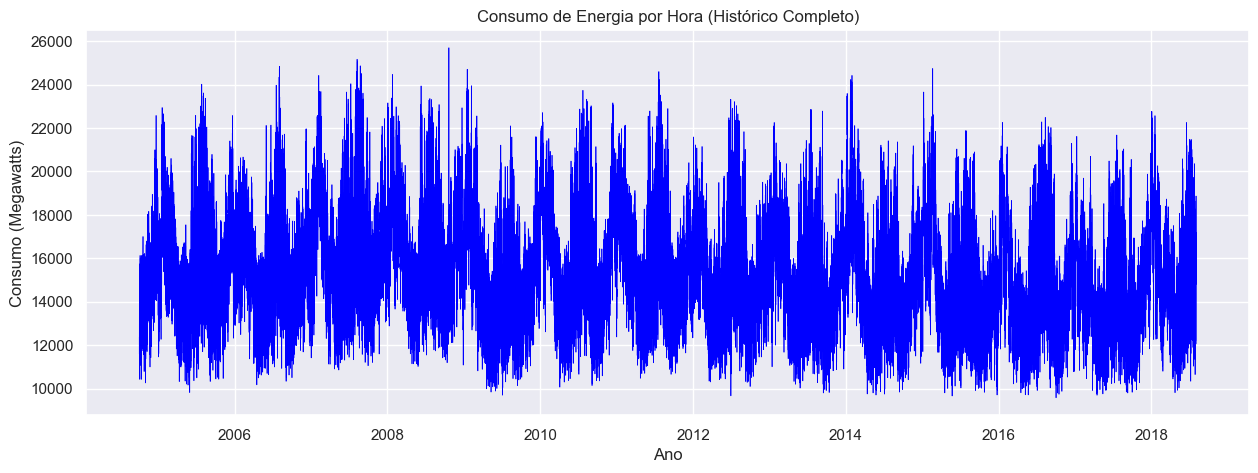

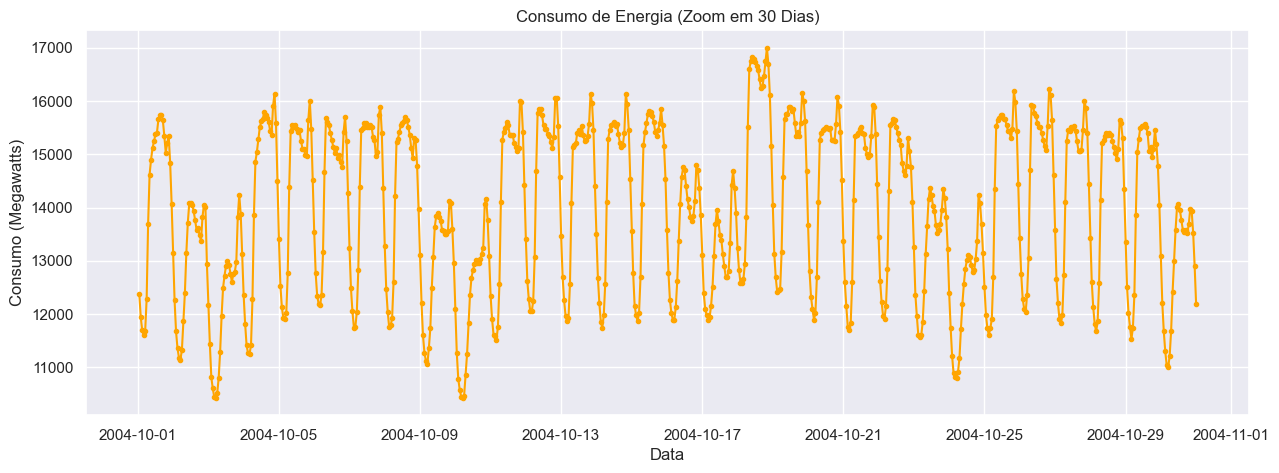

In [3]:
# Gráfico 1: Toda a série temporal
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['AEP_MW'], color='blue', linewidth=0.5)
plt.title('Consumo de Energia por Hora (Histórico Completo)')
plt.xlabel('Ano')
plt.ylabel('Consumo (Megawatts)')
plt.show()

# Gráfico 2: Zoom no primeiro mês de dados
zoom_df = df.iloc[:24*30] # Primeiras 720 horas (30 dias)

plt.figure(figsize=(15, 5))
plt.plot(zoom_df.index, zoom_df['AEP_MW'], color='orange', marker='o', markersize=3)
plt.title('Consumo de Energia (Zoom em 30 Dias)')
plt.xlabel('Data')
plt.ylabel('Consumo (Megawatts)')
plt.show()

In [ ]:
# Normalização dos Dados
scaler = MinMaxScaler(feature_range=(0, 1))
dados_escalados = scaler.fit_transform(df[['AEP_MW']])

# Função da Janela Deslizante
def criar_sequencias(dados, tamanho_janela_entrada):
    X, y = [], []
    for i in range(len(dados) - tamanho_janela_entrada):
        # Captura as N horas anteriores
        janela_x = dados[i : (i + tamanho_janela_entrada), 0]
        # Captura a hora seguinte
        alvo_y = dados[i + tamanho_janela_entrada, 0]
        
        X.append(janela_x)
        y.append(alvo_y)
        
    return np.array(X), np.array(y)

dias_entrada = 30
TAMANHO_JANELA_ENTRADA = 24*dias_entrada
X, y = criar_sequencias(dados_escalados, TAMANHO_JANELA_ENTRADA)

# Divisão Treino (70%), Validação (15%) e Teste (15%)
tamanho_total = len(X)
fim_treino = int(tamanho_total * 0.70)
fim_val = int(tamanho_total * 0.85)

# Conjunto de Treinamento
X_treino = X[:fim_treino]
y_treino = y[:fim_treino]

# Conjunto de Validação
X_val = X[fim_treino:fim_val]
y_val = y[fim_treino:fim_val]

# Conjunto de Teste
X_teste = X[fim_val:]
y_teste = y[fim_val:]

print(f"Total de sequências criadas: {tamanho_total}\n")
print(f"Treino:    X={X_treino.shape}, y={y_treino.shape}")
print(f"Validação: X={X_val.shape}, y={y_val.shape}")
print(f"Teste:     X={X_teste.shape}, y={y_teste.shape}")

Total de sequências criadas: 120553

Treino:    X=(84387, 720), y=(84387,)
Validação: X=(18083, 720), y=(18083,)
Teste:     X=(18083, 720), y=(18083,)


In [66]:
# --- PREPARAÇÃO DOS DATALOADERS ---

# Convertendo as matrizes Numpy para Tensores do PyTorch
X_treino_t = torch.tensor(X_treino, dtype=torch.float32)
y_treino_t = torch.tensor(y_treino, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_teste_t = torch.tensor(X_teste, dtype=torch.float32)
y_teste_t = torch.tensor(y_teste, dtype=torch.float32).view(-1, 1)

# Empacotando X e y juntos
dataset_treino = TensorDataset(X_treino_t, y_treino_t)
dataset_val = TensorDataset(X_val_t, y_val_t)
dataset_teste = TensorDataset(X_teste_t, y_teste_t)

# Criando os DataLoaders
loader_treino = DataLoader(dataset_treino, batch_size=64, shuffle=True, num_workers=4, persistent_workers=True)
loader_val = DataLoader(dataset_val, batch_size=64, shuffle=False, num_workers=4, persistent_workers=True)
loader_teste = DataLoader(dataset_teste, batch_size=64, shuffle=False, num_workers=4, persistent_workers=True)

## MLP

In [67]:
# --- DEFINIÇÃO DO MODELO (MLP) ---

class PrevisorEnergiaMLP(pl.LightningModule):
    def __init__(self, input_size):
        super().__init__()
        self.modelo = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Dropout para evitar (overfitting)
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Saída contínua
        )
        self.lr = 1e-3

    def forward(self, x):
        return self.modelo(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        previsoes = self(x)
        loss = nn.functional.mse_loss(previsoes, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        previsoes = self(x)
        loss = nn.functional.mse_loss(previsoes, y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

modelo_mlp = PrevisorEnergiaMLP(input_size=TAMANHO_JANELA_ENTRADA)
print(modelo_mlp)

PrevisorEnergiaMLP(
  (modelo): Sequential(
    (0): Linear(in_features=720, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10,
    mode='min'
)

trainer_mlp = Trainer(
    callbacks=[early_stopping], 
    max_epochs=100, 
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [70]:
print("Iniciando o Treinamento...")
trainer_mlp.fit(
    model=modelo_mlp, 
    train_dataloaders=loader_treino, 
    val_dataloaders=loader_val
)
print("Treinamento concluído!")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type       | Params | Mode  | FLOPs
------------------------------------------------------
0 | modelo | Sequential | 201 K  | train | 0    
------------------------------------------------------
201 K     Trainable params
0         Non-trainable params
201 K     Total params
0.804     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Iniciando o Treinamento...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


In [98]:
modelo_mlp.eval()
modelo_mlp.cuda()

with torch.no_grad():
    previsoes_teste = modelo_mlp(X_teste_t.cuda())

previsoes_np = previsoes_teste.cpu().numpy()
y_teste_np = y_teste_t.cpu().numpy()

previsoes_mw = scaler.inverse_transform(previsoes_np)
y_teste_mw = scaler.inverse_transform(y_teste_np)

print(y_teste_mw.shape)
print(previsoes_mw.shape)

(18083, 1)
(18083, 1)


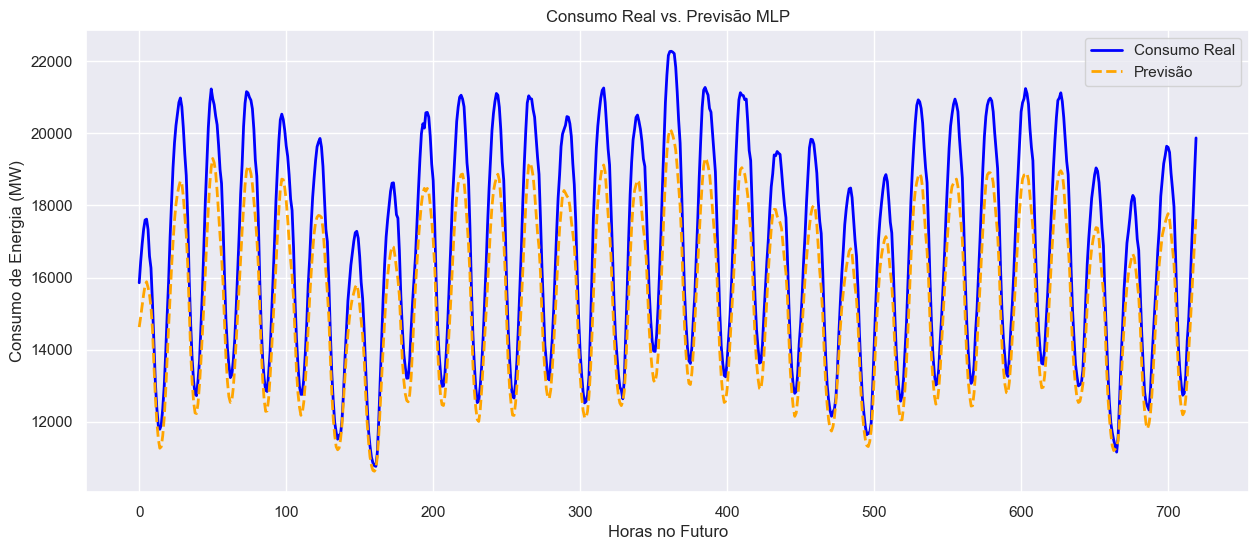

Erro Absoluto Médio (MAE): A rede está errando, em média, 942.83 Megawatts por hora.


In [104]:
dias = 30
amostra = 24*dias

plt.figure(figsize=(15, 6))
plt.plot(y_teste_mw[:amostra, 0], label='Consumo Real', color='blue', linewidth=2)
plt.plot(previsoes_mw[:amostra, 0], label='Previsão', color='orange', linestyle='dashed', linewidth=2)

plt.title('Consumo Real vs. Previsão MLP')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

# Calcular métrica de erro (MAE - Erro Absoluto Médio)
from sklearn.metrics import mean_absolute_error
erro_mae = mean_absolute_error(y_teste_mw, previsoes_mw)
print(f"Erro Absoluto Médio (MAE): A rede está errando, em média, {erro_mae:.2f} Megawatts por hora.")

In [73]:
trainer_mlp.save_checkpoint("mlp.ckpt")
print("Modelo salvo com sucesso no disco!")

`weights_only` was not set, defaulting to `False`.


Modelo salvo com sucesso no disco!


## CNN

In [ ]:
# --- ARQUITETURA DA CNN 1D ---

class PrevisorEnergiaCNN(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        # Extrator de Características Temporais
        self.conv_layers = nn.Sequential(
            # kernel_size=24: O filtro "lê" 1 dia inteiro por vez
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=24), 
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            # kernel_size=12: O filtro "lê" meio dia de padrões mais refinados
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=12), 
            nn.ReLU(),
            
            nn.AdaptiveAvgPool1d(1) 
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
        self.lr = 1e-3

    def forward(self, x):
        #Transforma [Batch, 720] em [Batch, 1, 720] para a CNN
        x = x.unsqueeze(1) 
        
        features = self.conv_layers(x)
        saida = self.fc(features)
        return saida

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)
    

modelo_cnn = PrevisorEnergiaCNN()
print(modelo_cnn)

PrevisorEnergiaCNN(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(24,), stride=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(12,), stride=(1,))
    (4): ReLU()
    (5): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
early_stopping_cnn = EarlyStopping(
  monitor='val_loss', 
  patience=10, 
  mode='min')

trainer_cnn = Trainer(
    callbacks=[early_stopping_cnn], 
    max_epochs=100,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [78]:
print("Iniciando Treinamento da CNN 1D...")

trainer_cnn.fit(modelo_cnn, loader_treino, loader_val)

print("Treinamento concluído!")

c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\biridhin\Downloads\Trabalho Final\lightning_logs\version_5\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type       | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | conv_layers | Sequential | 25.4 K | train | 0    
1 | fc          | Sequential | 2.1 K  | train | 0    
-----------------------------------------------------------
27.6 K    Trainable params
0         Non-trainable params
27.6 K    Total params
0.110     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode
0         Total Flops


Iniciando Treinamento da CNN 1D...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


In [80]:
print("Avaliando o modelo CNN...")
modelo_cnn.cuda() # Evitar travamentos
modelo_cnn.eval()

with torch.no_grad():
    previsoes_teste_cnn = modelo_cnn(X_teste_t.cuda())

previsoes_mw_cnn = scaler.inverse_transform(previsoes_teste_cnn.cpu().numpy())

Avaliando o modelo CNN...


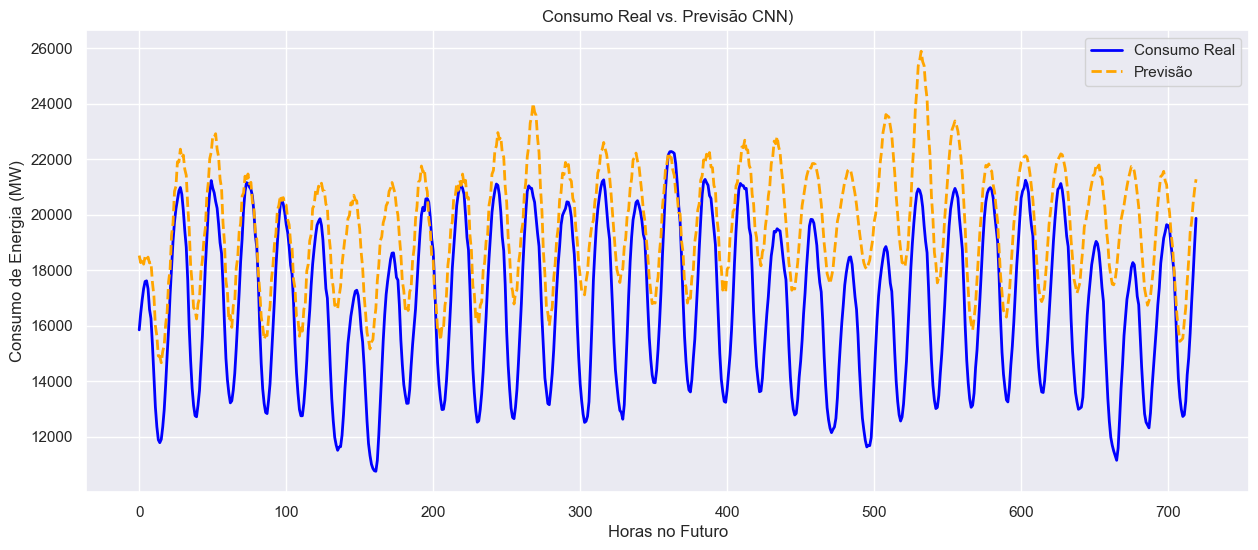

Erro Absoluto Médio (MAE) da CNN: 1499.69 MW por hora.


In [81]:
dias = 30
amostra = 24*dias

plt.figure(figsize=(15, 6))

plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='blue', linewidth=2)
plt.plot(previsoes_mw_cnn[:amostra], label='Previsão', color='orange', linestyle='dashed', linewidth=2)

plt.title('Consumo Real vs. Previsão CNN)')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

erro_mae_cnn = mean_absolute_error(y_teste_mw, previsoes_mw_cnn)
print(f"Erro Absoluto Médio (MAE) da CNN: {erro_mae_cnn:.2f} MW por hora.")

In [82]:
trainer_cnn.save_checkpoint("cnn.ckpt")
print("Modelo salvo com sucesso no disco!")

`weights_only` was not set, defaulting to `False`.


Modelo salvo com sucesso no disco!


### CNN sem pooling

In [83]:
# --- ARQUITETURA DA CNN 1D (SEM POOLING) ---

class PrevisorCNN2(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        # Extrator de Características (Apenas Convoluções pularam o Pooling)
        self.conv_layers = nn.Sequential(
            # Entra 720, sai 697
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=24), 
            nn.ReLU(),
            
            # Entra 697, sai 686
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=12), 
            nn.ReLU()
        )
        
        # Classificador Final (Agora ele precisa engolir 43.904 conexões)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 686, 32), # A grande mudança está aqui!
            nn.ReLU(),
            nn.Dropout(0.3), # Aumentei o Dropout levemente para evitar overfitting
            nn.Linear(32, 1)
        )
        self.lr = 1e-3

    def forward(self, x):
        x = x.unsqueeze(1) 
        features = self.conv_layers(x)
        saida = self.fc(features)
        return saida

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


modelo_cnn2 = PrevisorCNN2()
print(modelo_cnn2)

PrevisorCNN2(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(24,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(12,), stride=(1,))
    (3): ReLU()
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43904, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [84]:
early_stopping_bruta = EarlyStopping(
  monitor='val_loss', 
  patience=10, 
  mode='min')

trainer_cnn2 = Trainer(
    callbacks=[early_stopping_bruta], 
    max_epochs=100, 
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [85]:
print("Iniciando Treinamento da CNN (Força Bruta sem Pooling)...")
trainer_cnn2.fit(modelo_cnn2, loader_treino, loader_val)
print("Treinamento concluído!")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Iniciando Treinamento da CNN (Força Bruta sem Pooling)...



  | Name        | Type       | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | conv_layers | Sequential | 25.4 K | train | 0    
1 | fc          | Sequential | 1.4 M  | train | 0    
-----------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.722     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


In [102]:
modelo_cnn2.cuda()
modelo_cnn2.eval()

with torch.no_grad():
    previsoes_teste = modelo_cnn2(X_teste_t.cuda())

previsoes_mw_cnn2 = scaler.inverse_transform(previsoes_teste.cpu().numpy())

erro_mae_cnn2 = mean_absolute_error(y_teste_mw, previsoes_mw_cnn2)
print(f"\nResultado da Batalha:")
print(f"Erro CNN original (com pooling): 1347.11 MW")
print(f"Erro CNN nova (sem pooling): {erro_mae_cnn2:.2f} MW")


Resultado da Batalha:
Erro CNN original (com pooling): 1347.11 MW
Erro CNN nova (sem pooling): 520.45 MW


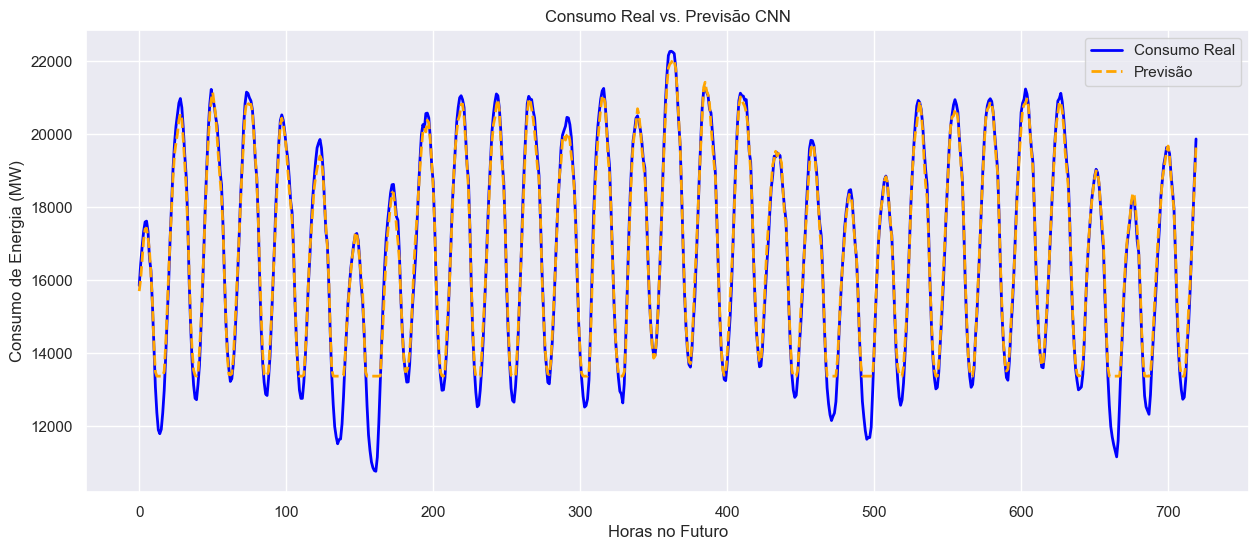

In [103]:
dias = 30
amostra = 24*dias

plt.figure(figsize=(15, 6))

# Plotando a linha do consumo real (em azul)
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='blue', linewidth=2)

# Plotando a linha da previsão da CNN (em laranja e tracejada)
plt.plot(previsoes_mw_cnn2[:amostra], label='Previsão', color='orange', linestyle='dashed', linewidth=2)

# Configurações visuais do gráfico
plt.title('Consumo Real vs. Previsão CNN')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

In [88]:
trainer_cnn2.save_checkpoint("cnn2.ckpt")
print("Modelo salvo com sucesso no disco!")

`weights_only` was not set, defaulting to `False`.


Modelo salvo com sucesso no disco!


## LSTM

In [89]:
# --- ARQUITETURA DA REDE LSTM ---

class PrevisorEnergiaLSTM(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, num_layers=2, batch_first=True, dropout=0.2)
        
        # Classificador Final
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.lr = 1e-3

    def forward(self, x):
        # Transforma [Batch, 720] em [Batch, 720, 1] para a LSTM
        x = x.unsqueeze(-1)
        
        # A LSTM retorna as saídas de todos os passos e o estado da memória (hn, cn)
        saida_lstm, (hn, cn) = self.lstm(x)
        
        ultimo_passo = saida_lstm[:, -1, :]
        
        saida = self.fc(ultimo_passo)
        return saida

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


modelo_lstm = PrevisorEnergiaLSTM()
print(modelo_lstm)

PrevisorEnergiaLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [90]:
early_stopping_lstm = EarlyStopping(
  monitor='val_loss', 
  patience=10, 
  mode='min')

trainer_lstm = Trainer(
    callbacks=[early_stopping_lstm], 
    max_epochs=100,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [91]:
print("Iniciando Treinamento da LSTM...")

trainer_lstm.fit(modelo_lstm, loader_treino, loader_val)

print("Treinamento concluído!")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Iniciando Treinamento da LSTM...



  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | lstm | LSTM       | 50.4 K | train | 0    
1 | fc   | Sequential | 2.1 K  | train | 0    
----------------------------------------------------
52.5 K    Trainable params
0         Non-trainable params
52.5 K    Total params
0.210     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


In [92]:
print("Avaliando o modelo LSTM em lotes...")
modelo_lstm.cpu()
modelo_lstm.eval()

previsoes_lista = []

with torch.no_grad():
    for x_lote, _ in loader_teste:
        saida_lote = modelo_lstm(x_lote)
        previsoes_lista.append(saida_lote)

# Junta todos os pequenos blocos de 64 de volta em um único vetor
previsoes_teste_lstm = torch.cat(previsoes_lista, dim=0)

# Reverte a escala para Megawatts
previsoes_mw_lstm = scaler.inverse_transform(previsoes_teste_lstm.numpy())

erro_mae_lstm = mean_absolute_error(y_teste_mw, previsoes_mw_lstm)
print(f"Erro Absoluto Médio (MAE) da LSTM: {erro_mae_lstm:.2f} MW por hora.")

Avaliando o modelo LSTM em lotes...
Erro Absoluto Médio (MAE) da LSTM: 114.20 MW por hora.


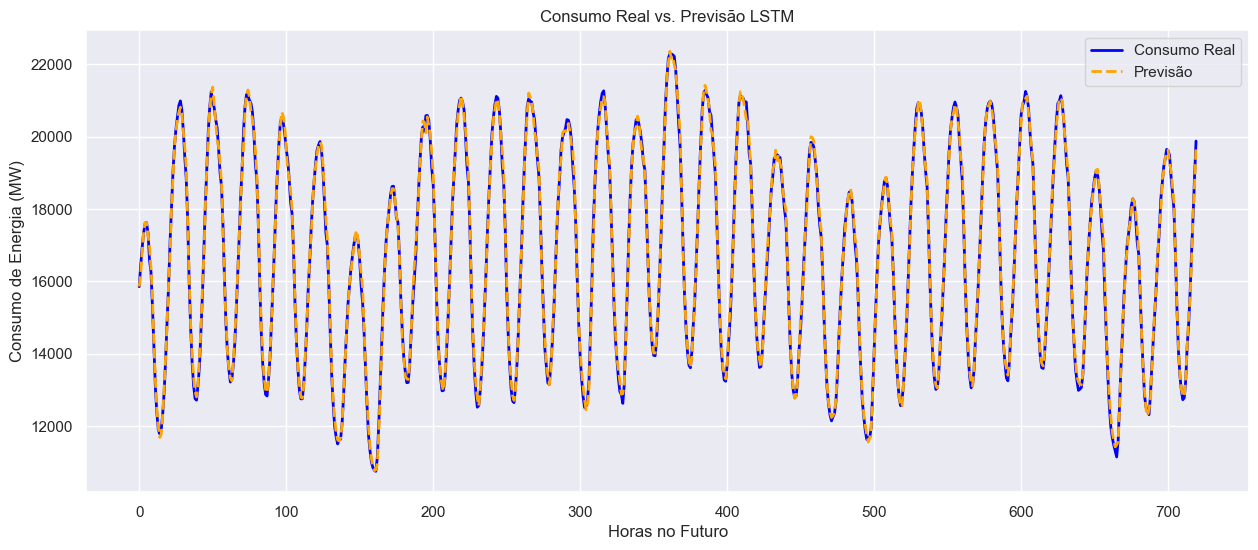

In [93]:
dias = 30
amostra = 24*dias

plt.figure(figsize=(15, 6))

# Plotando a linha do consumo real (em azul)
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='blue', linewidth=2)

# Plotando a linha da previsão da CNN (em laranja e tracejada)
plt.plot(previsoes_mw_lstm[:amostra], label='Previsão', color='orange', linestyle='dashed', linewidth=2)

# Configurações visuais do gráfico
plt.title('Consumo Real vs. Previsão LSTM')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

In [94]:
trainer_lstm.save_checkpoint("lstm.ckpt")
print("Modelo salvo com sucesso no disco!")

`weights_only` was not set, defaulting to `False`.


Modelo salvo com sucesso no disco!


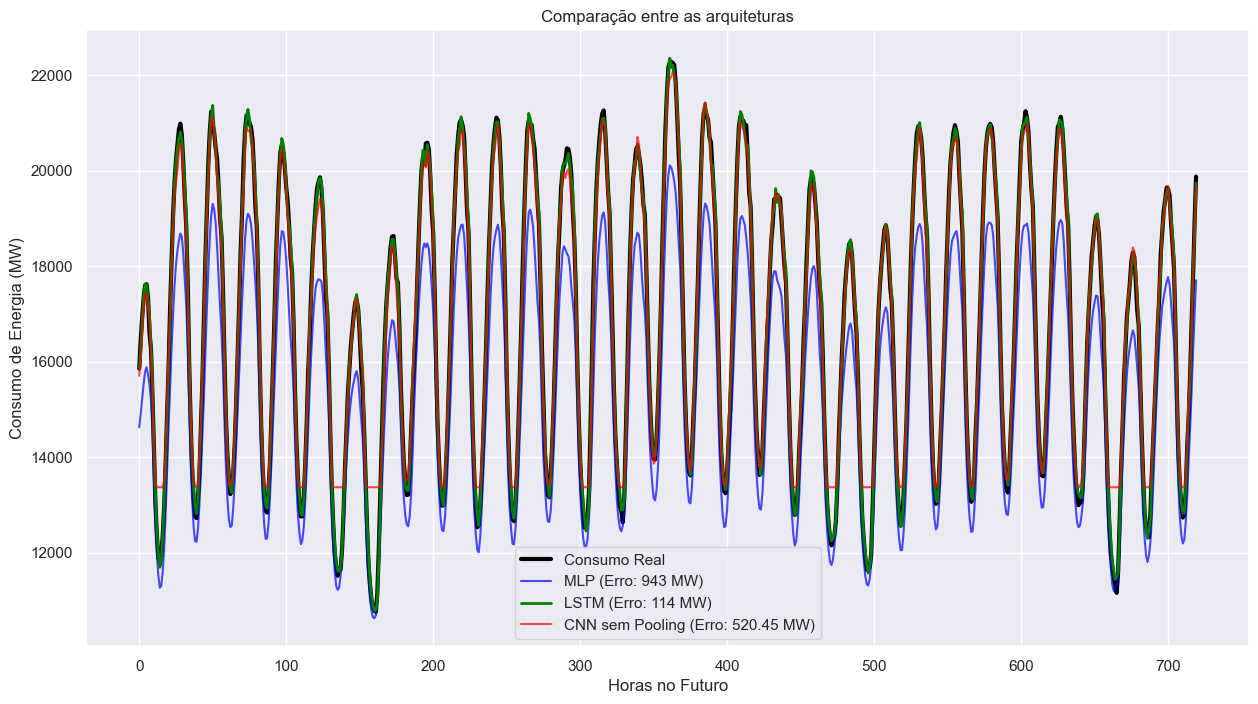

In [105]:
dias = 30
amostra = 24*dias

plt.figure(figsize=(15, 8))
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='black', linewidth=3)
plt.plot(previsoes_mw[:amostra], label=f'MLP (Erro: {erro_mae:.0f} MW)', color='blue', alpha=0.7)
#plt.plot(previsoes_mw_cnn[:amostra], label=f'CNN 1D (Erro: {erro_mae_cnn:.0f} MW)', color='orange', alpha=0.7)
plt.plot(previsoes_mw_lstm[:amostra], label=f'LSTM (Erro: {erro_mae_lstm:.0f} MW)', color='green', linewidth=2)
plt.plot(previsoes_mw_cnn2[:amostra], label=f'CNN sem Pooling (Erro: {erro_mae_cnn2:.2f} MW)', color='red', alpha=0.7)

plt.title('Comparação entre as arquiteturas')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()